# Lab 1: Perceptrons and Linear Separability

**Module:** Artificial Intelligence  
**Topic:** Neural Networks - Part 1

## Learning Objectives
>By the end of this lab, you will be able to:
>1. Implement a Rosenblatt perceptron from scratch in Python
>2. Train a perceptron to learn the logical AND and OR operations
>3. Visualise how the decision boundary adapts during training
>4. Understand why a single-layer perceptron cannot learn XOR (linear separability)
>5. Implement a two-layer perceptron to solve the XOR problem


## Background

A **Rosenblatt perceptron** is the simplest form of a neural network, consisting of:
- A set of input values ($x_1, x_2, \ldots, x_n$)
- A weight for each input ($w_1, w_2, \ldots, w_n$)
- A bias term ($b$) or threshold ($\theta$)
- An activation function (step function for the classic perceptron)

The perceptron computes:

$$y = \text{step}\left(\sum_{i=1}^{n} x_i \cdot w_i + b\right)$$

where the step function returns 1 if the input $\geq 0$, and 0 otherwise.

**The Perceptron Learning Rule:**

$$w_i^{(\text{new})} = w_i^{(\text{old})} + \alpha \cdot (y_d - y) \cdot x_i$$

where $\alpha$ is the learning rate, $y_d$ is the desired output, and $y$ is the actual output.

## Setup
First, import the necessary libraries. We'll use NumPy for numerical operations and Matplotlib for visualisation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
# Configure matplotlib for better display
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["font.size"] = 12

## Exercise 1: Implement a Perceptron Class

Create a `Perceptron` class with the following structure:

**Requirements:**

1. **`__init__(self, n_inputs, learning_rate=0.1)`**
   - Initialise weights to small random values (e.g., between -0.5 and 0.5)
   - Initialise bias to 0 or a small random value
   - Store the learning rate
   - *Hint:* Use `np.random.uniform(-0.5, 0.5, size=n_inputs)` for weights

2. **`step_function(self, x)`**
   - Return 1 if x >= 0, else return 0
   - *Hint:* Can be done in one line with `int(x >= 0)` or using NumPy

3. **`predict(self, inputs)`**
   - Compute the weighted sum: $\sum_i x_i \cdot w_i + b$
   - Apply the step function
   - Return the result (0 or 1)
   - *Hint:* Use `np.dot(inputs, self.weights)` plus bias for the weighted sum

4. **`train(self, X, y, epochs, verbose=True)`**
   - For each epoch, iterate through all training samples
   - For each sample: predict, compute error, update weights and bias
   - Weight update: $w_i = w_i + \alpha \cdot \text{error} \cdot x_i$
   - Bias update: $b = b + \alpha \cdot \text{error}$
   - Track and return the history of weights for visualisation
   - *Hint:* use `history.append((self.weights.copy(), self.bias))` to store weights after each epoch in a list

In [3]:
class Perceptron:
    """
    A simple Rosenblatt Perceptron implementation.
    """

    def __init__(self, n_inputs, learning_rate=0.1):
        """
        Initialise the perceptron.

        Parameters:
        -----------
        n_inputs : int
        Number of input features
        learning_rate : float
        Learning rate (alpha) for weight updates
        """
        # TODO: add code here to initialise weights to small random values (e.g., -0.5..0.5)
        ## See hint in the markdown cell above
        self.weights = np.random.uniform(-0.5, 0.5, size=n_inputs)
        self.bias = np.random.uniform(-0.5, 0.5)
        self.learning_rate = learning_rate

    def step_function(self, x):
        """
        Step activation function.

        Returns 1 if x >= 0, else 0.
        """
        # TODO: add code here to return 1 if x ≥ 0, else return 0
        ## See hint in the markdown cell above
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        """
        Compute the perceptron output for given inputs.

        Parameters:
        -----------
        inputs : array-like
        Input values (x1, x2, ...)

        Returns:
        --------
        int : 0 or 1
        """
        # TODO: add code here to compute the weighted sum
        ## See hint in the markdown cell above
        weighted_sum = np.dot(inputs, self.weights) + self.bias

        return self.step_function(weighted_sum)

    def train(self, X, y, epochs, verbose=True):
        """
        Train the perceptron using the perceptron learning rule.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
        Training inputs
        y : array-like, shape (n_samples,)
        Target outputs (0 or 1)
        epochs : int
        Number of training epochs
        verbose : bool
        If True, print weights after each epoch

        Returns:
        --------
        list : History of (weights, bias) tuples for each epoch
        """
        history = []

        # Store initial weights
        history.append((self.weights.copy(), self.bias))

        for epoch in range(epochs):
            total_error = 0

            for i in range(len(X)):
                # Get prediction
                prediction = self.predict(X[i])

                # Calculate error
                error = y[i] - prediction
                total_error += abs(error)

                # Update weights and bias
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error

            # Store weights after this epoch
            # TODO: add code here to store weights after each epoch in a list
            ## See hint in the markdown cell above
            history.append((self.weights.copy(), self.bias))

            if verbose:
                print(
                    f"Epoch {epoch + 1}: weights = {self.weights}, bias = {self.bias:.4f}, errors = {total_error}"
                )

            # Early stopping if no errors
            if total_error == 0:
                if verbose:
                    print(f"Converged after {epoch + 1} epochs!")
                break

        return history

## Exercise 2: Train the Perceptron for Logical AND

The logical AND operation has the following truth table:

| $x_1$ | $x_2$ | AND |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

### Task 2.1: Define the Training Data

Create:
- `X_and`: A 2D NumPy array with all input combinations
- `y_and`: A 1D NumPy array with the expected outputs

In [4]:
# Define training data for AND
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
print("AND Training Data:")
print("X:")
print(X_and)
print("y:", y_and)

AND Training Data:
X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [0 0 0 1]


### Task 2.2: Train and Test the Perceptron

1. Create a perceptron with 2 inputs
2. Train it for 10 epochs (this should be sufficient for AND)
3. Test on all input combinations and verify correctness

*Note:* ✓ is \u2713, ✗ is \u2717

In [5]:
# Create perceptron
perceptron_and = Perceptron(n_inputs=2, learning_rate=0.1)
print("Initial weights:", perceptron_and.weights)
print("Initial bias:", perceptron_and.bias)
print("\nTraining...\n")
# Train (store the history for later visualisation)
history_and = perceptron_and.train(X_and, y_and, epochs=10)
# Test on all inputs
print("\nTesting AND perceptron:")
print("-" * 40)
all_correct = True
for i in range(len(X_and)):
    prediction = perceptron_and.predict(X_and[i])
    correct = "✓" if prediction == y_and[i] else "✗"
    if prediction != y_and[i]:
        all_correct = False
    print(
        f"Input: {X_and[i]} -> Predicted: {prediction}, Expected: {y_and[i]} {correct}"
    )
print("-" * 40)
print(f"All predictions correct: {all_correct}")

Initial weights: [-0.12545988  0.45071431]
Initial bias: 0.2319939418114051

Training...

Epoch 1: weights = [-0.12545988  0.35071431], bias = 0.0320, errors = 2
Epoch 2: weights = [-0.02545988  0.35071431], bias = -0.0680, errors = 3
Epoch 3: weights = [-0.02545988  0.25071431], bias = -0.1680, errors = 1
Epoch 4: weights = [0.07454012 0.25071431], bias = -0.1680, errors = 2
Epoch 5: weights = [0.17454012 0.25071431], bias = -0.1680, errors = 2
Epoch 6: weights = [0.17454012 0.15071431], bias = -0.2680, errors = 1
Epoch 7: weights = [0.17454012 0.15071431], bias = -0.2680, errors = 0
Converged after 7 epochs!

Testing AND perceptron:
----------------------------------------
Input: [0 0] -> Predicted: 0, Expected: 0 ✓
Input: [0 1] -> Predicted: 0, Expected: 0 ✓
Input: [1 0] -> Predicted: 0, Expected: 0 ✓
Input: [1 1] -> Predicted: 1, Expected: 1 ✓
----------------------------------------
All predictions correct: True


### Task 2.3: Visualise the Decision Boundary

The decision boundary of a perceptron is a line defined by:

$$w_1 \cdot x_1 + w_2 \cdot x_2 + b = 0$$

Rearranging for $x_2$:

$$x_2 = -\frac{w_1}{w_2} \cdot x_1 - \frac{b}{w_2}$$

Create a function to plot:
1. The four data points (use different colours/markers for 0 and 1)
2. The decision boundary line

*Hint:* Use `plt.scatter()` for points and `plt.plot()` for the line.

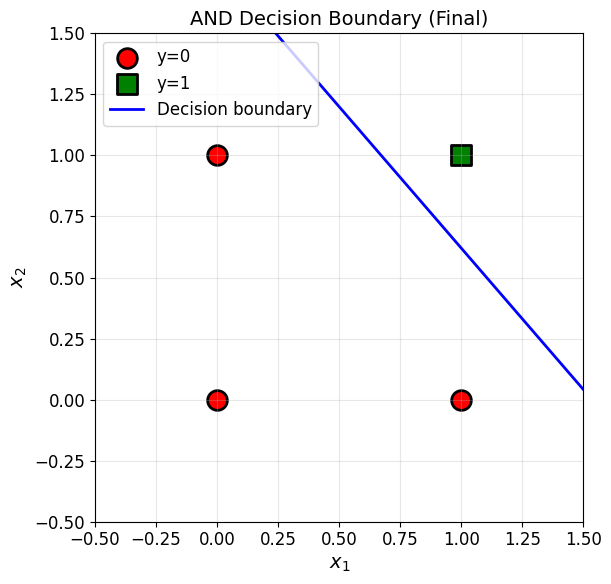

In [6]:
# Plotting function
def plot_decision_boundary(X, y, weights, bias, title="Decision Boundary", ax=None):
    """
    Plot data points and decision boundary.

    Parameters:
    -----------
    X : array-like, shape (n_samples, 2)
    Input data points
    y : array-like, shape (n_samples,)
    Labels (0 or 1)
    weights : array-like, shape (2,)
    Perceptron weights [w1, w2]
    bias : float
    Perceptron bias
    title : str
    Plot title
    ax : matplotlib axis (optional)
    Axis to plot on. If None, creates new figure.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Plot points
    for i in range(len(X)):
        if y[i] == 0:
            ax.scatter(
                X[i, 0],
                X[i, 1],
                c="red",
                marker="o",
                s=200,
                edgecolors="black",
                linewidths=2,
                label="y=0" if i == 0 else "",
            )
        else:
            ax.scatter(
                X[i, 0],
                X[i, 1],
                c="green",
                marker="s",
                s=200,
                edgecolors="black",
                linewidths=2,
                label="y=1" if i == 3 else "",
            )

    # Plot decision boundary
    # Line: w1*x1 + w2*x2 + b = 0
    # => x2 = -(w1/w2)*x1 - b/w2

    x1_range = np.linspace(-0.5, 1.5, 100)

    if abs(weights[1]) > 1e-10:  # Avoid division by zero
        x2_boundary = -(weights[0] / weights[1]) * x1_range - (bias / weights[1])
        ax.plot(x1_range, x2_boundary, "b-", linewidth=2, label="Decision boundary")
    else:
        # Vertical line case
        if abs(weights[0]) > 1e-10:
            x1_boundary = -bias / weights[0]
            ax.axvline(x=x1_boundary, color="b", linewidth=2, label="Decision boundary")

    # Formatting
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("$x_1$", fontsize=14)
    ax.set_ylabel("$x_2$", fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    ax.set_aspect("equal")

    return ax


# Test the plotting function with the trained AND perceptron
plot_decision_boundary(
    X_and,
    y_and,
    perceptron_and.weights,
    perceptron_and.bias,
    "AND Decision Boundary (Final)",
)
plt.tight_layout()
plt.show()

### Task 2.4: Animate the Learning Process

Create a visualisation showing how the decision boundary changes across epochs.

You can either:
- Create a single figure with multiple subplots (one per epoch)
- Create multiple separate figures

*Hint:* Use the weight history returned from training.

AND - Decision Boundary Evolution:


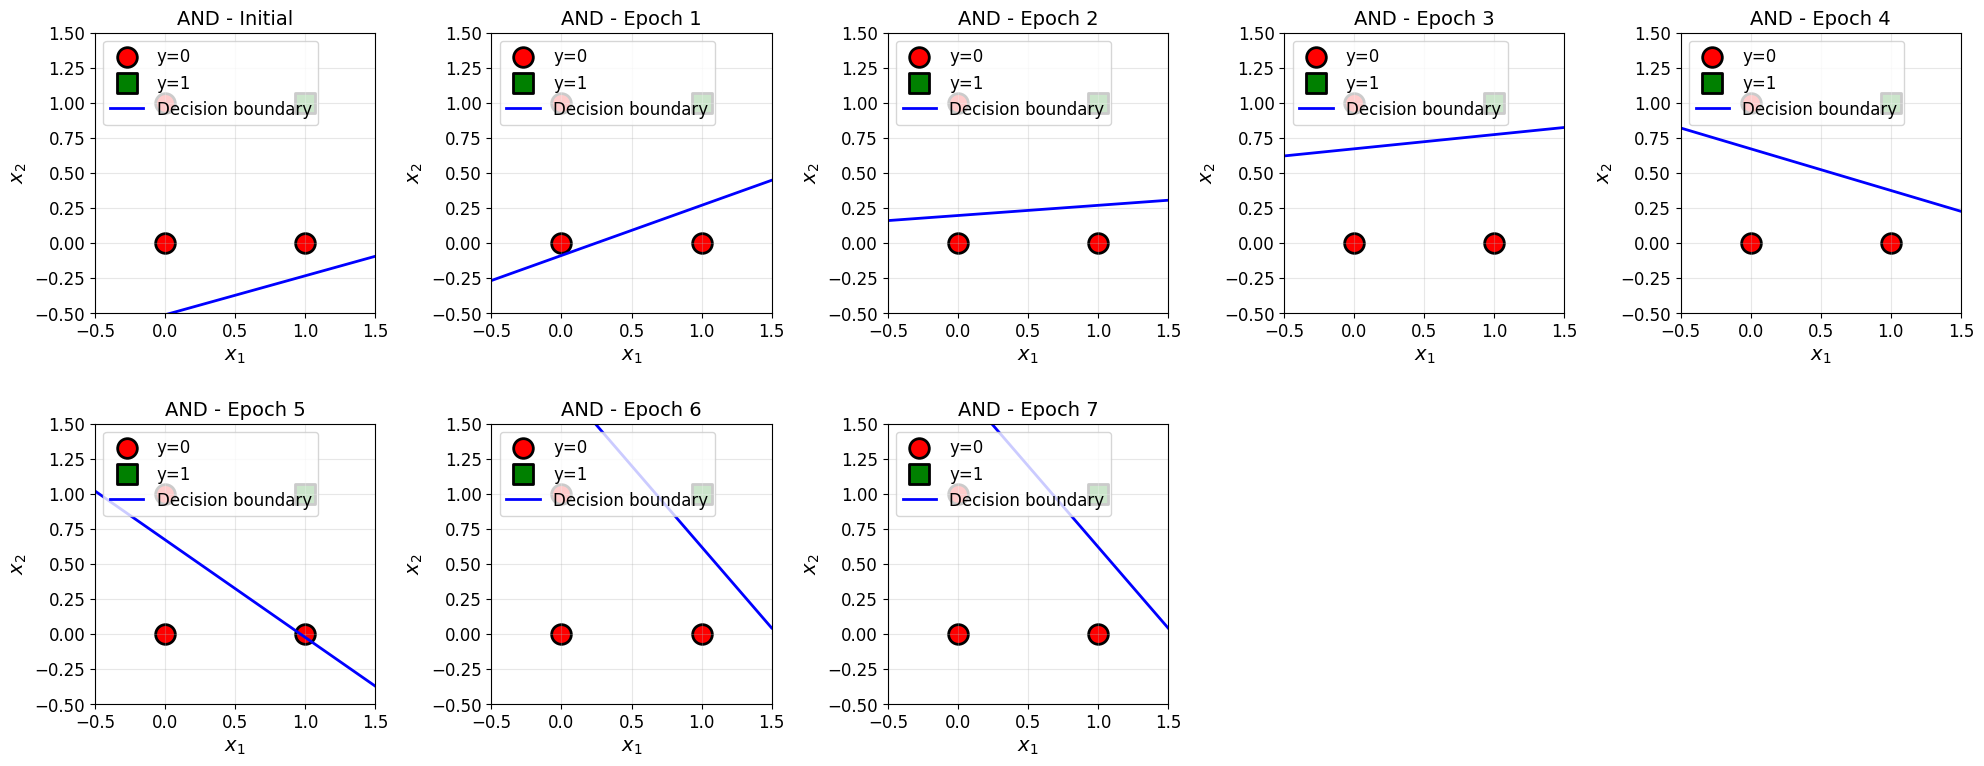

In [7]:
# Visualise decision boundary evolution across epochs
def plot_training_evolution(X, y, history, title_prefix=""):
    """
    Plot decision boundary evolution across training epochs.
    """
    n_epochs = len(history)

    # Determine grid size
    n_cols = min(5, n_epochs)
    n_rows = (n_epochs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

    # Handle single row case
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (weights, bias) in enumerate(history):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]

        epoch_label = "Initial" if idx == 0 else f"Epoch {idx}"
        plot_decision_boundary(
            X, y, weights, bias, f"{title_prefix}{epoch_label}", ax=ax
        )

    # Hide empty subplots
    for idx in range(n_epochs, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


# Plot AND training evolution
print("AND - Decision Boundary Evolution:")
plot_training_evolution(X_and, y_and, history_and, "AND - ")

### Task 2.5: Display Weight Updates Table

Create a table showing the weight values at each epoch, similar to the table shown in the lecture slides.

The table should include:
- Epoch number
- Weight values ($w_1$, $w_2$)
- Bias value ($b$)

*Hint:* You can use pandas DataFrame for a nicely formatted table, or just print formatted strings.

In [8]:
import pandas as pd


def create_weight_table(history):
    """
    Create a pandas DataFrame showing weights at each epoch.
    """
    data = {"Epoch": [], "w₁": [], "w₂": [], "bias": []}

    for epoch, (weights, bias) in enumerate(history):
        data["Epoch"].append("Initial" if epoch == 0 else epoch)
        data["w₁"].append(f"{weights[0]:.4f}")
        data["w₂"].append(f"{weights[1]:.4f}")
        data["bias"].append(f"{bias:.4f}")

    return pd.DataFrame(data)


print("AND - Weight History Table:")
df_and = create_weight_table(history_and)
display(df_and)

AND - Weight History Table:


,Epoch,w₁,w₂,bias
0,Initial,-0.1255,0.4507,0.2320
1,1,-0.1255,0.3507,0.0320
2,2,-0.0255,0.3507,-0.0680
3,3,-0.0255,0.2507,-0.1680
4,4,0.0745,0.2507,-0.1680
5,5,0.1745,0.2507,-0.1680
6,6,0.1745,0.1507,-0.2680
7,7,0.1745,0.1507,-0.2680


## Exercise 3: Train the Perceptron for Logical OR

The logical OR operation has the following truth table:

| $x_1$ | $x_2$ | OR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

### Task 3.1: Define Data, Train, and Visualise

Repeat the process from Exercise 2, but now for the OR operation:

- **3.1.1.** Define the training data
- **3.1.2.** Train a new perceptron
- **3.1.3.** Test and verify
- **3.1.4.** Visualise the decision boundary (part of Task 3.2)

In [9]:
# Define training data for OR
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])
print("OR Training Data:")
print("X:")
print(X_or)
print("y:", y_or)

OR Training Data:
X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [0 1 1 1]


In [10]:
# Create perceptron
perceptron_or = Perceptron(n_inputs=2, learning_rate=0.1)
print("Initial weights:", perceptron_or.weights)
print("Initial bias:", perceptron_or.bias)
print("\nTraining...\n")
# Train (store the history for later visualisation)
history_or = perceptron_or.train(X_or, y_or, epochs=10)
# Test on all inputs
print("\nTesting OR perceptron:")
print("-" * 40)
all_correct = True
for i in range(len(X_or)):
    prediction = perceptron_or.predict(X_or[i])
    correct = "✓" if prediction == y_or[i] else "✗"
    if prediction != y_or[i]:
        all_correct = False
    print(
        f"Input: {X_or[i]} -> Predicted: {prediction}, Expected: {y_or[i]} {correct}"
    )
print("-" * 40)
print(f"All predictions correct: {all_correct}")

Initial weights: [ 0.09865848 -0.34398136]
Initial bias: -0.34400547966379735

Training...

Epoch 1: weights = [ 0.29865848 -0.14398136], bias = -0.0440, errors = 3
Epoch 2: weights = [ 0.29865848 -0.04398136], bias = 0.0560, errors = 1
Epoch 3: weights = [0.29865848 0.05601864], bias = 0.0560, errors = 2
Epoch 4: weights = [0.29865848 0.05601864], bias = -0.0440, errors = 1
Epoch 5: weights = [0.29865848 0.05601864], bias = -0.0440, errors = 0
Converged after 5 epochs!

Testing OR perceptron:
----------------------------------------
Input: [0 0] -> Predicted: 0, Expected: 0 ✓
Input: [0 1] -> Predicted: 1, Expected: 1 ✓
Input: [1 0] -> Predicted: 1, Expected: 1 ✓
Input: [1 1] -> Predicted: 1, Expected: 1 ✓
----------------------------------------
All predictions correct: True


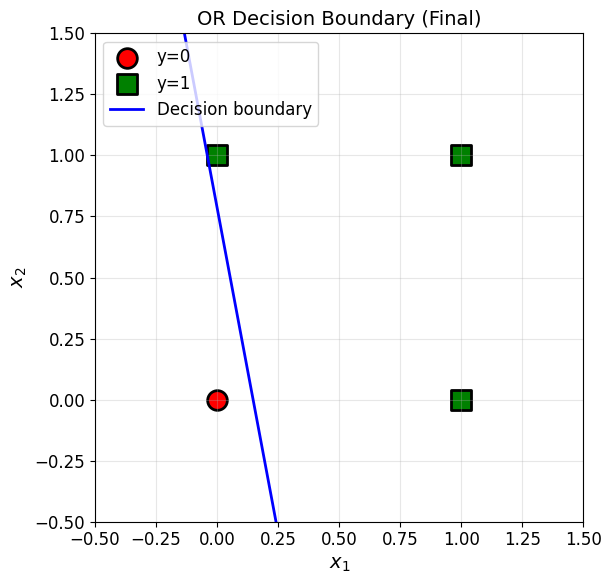

In [11]:
# TODO: add code here to plot the decision boundary
## Hint: reuse the "plot_decision_boundary" method you've already defined in Task 2.3
# Plotting function

plot_decision_boundary(
    X_or,
    y_or,
    perceptron_or.weights,
    perceptron_or.bias,
    "OR Decision Boundary (Final)",
)
plt.tight_layout()
plt.show()

In [12]:
# TODO: add code here to draw the weight history table
## Hint: reuse the "create_weight_table" method you've already defined in Task 2.5
print("OR - Weight History Table:")
df_or = create_weight_table(history_or)
display(df_or)

OR - Weight History Table:


,Epoch,w₁,w₂,bias
0,Initial,0.0987,-0.3440,-0.3440
1,1,0.2987,-0.1440,-0.0440
2,2,0.2987,-0.0440,0.0560
3,3,0.2987,0.0560,0.0560
4,4,0.2987,0.0560,-0.0440
5,5,0.2987,0.0560,-0.0440


### Task 3.2: Compare AND and OR Decision Boundaries

Create a side-by-side comparison of the AND and OR decision boundaries.

**Discussion Questions:**
- How do the slopes of the decision boundaries differ?
- What is the geometric interpretation of the difference?
- Why are both problems solvable by a single perceptron?

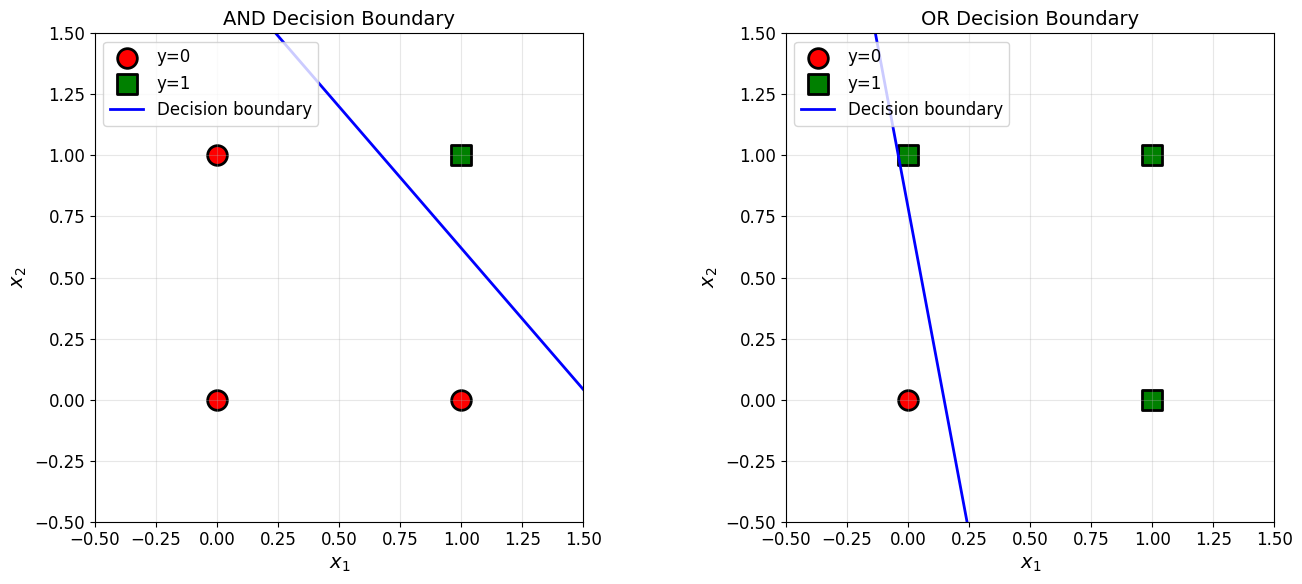

Discussion:
------------------------------------------------------------
AND: The decision boundary separates (1,1) from the other three points.
 The line passes 'above' most points, classifying only the top-right as 1.

OR: The decision boundary separates (0,0) from the other three points.
 The line passes 'below' most points, classifying only the origin as 0.

Both are solvable because in each case, the two classes can be separated
by a single straight line - they are LINEARLY SEPARABLE.


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(X_and, y_and, perceptron_and.weights, perceptron_and.bias,
"AND Decision Boundary", ax=ax1)
# TODO: add code here to plot the OR decision boundary
plot_decision_boundary(X_or, y_or, perceptron_or.weights, perceptron_or.bias,
"OR Decision Boundary", ax=ax2)

plt.tight_layout()
plt.show()
# Discussion
print("Discussion:")
print("-" * 60)
print("AND: The decision boundary separates (1,1) from the other three points.")
print(" The line passes 'above' most points, classifying only the top-right as 1.")
print()
print("OR: The decision boundary separates (0,0) from the other three points.")
print(" The line passes 'below' most points, classifying only the origin as 0.")
print()
print("Both are solvable because in each case, the two classes can be separated")
print("by a single straight line - they are LINEARLY SEPARABLE.")

## Exercise 4: The XOR Problem – Demonstrating Linear Inseparability

The logical XOR (exclusive OR) operation has the following truth table:

| $x_1$ | $x_2$ | XOR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

### Task 4.1: Attempt to Train a Single Perceptron for XOR

Try training a single-layer perceptron on the XOR problem.

**Prediction:** The perceptron will NOT converge to a correct solution.

- **4.1.1.** Define XOR training data
- **4.1.2.** Attempt to train a perceptron for XOR
- **4.1.3.** Test the XOR perceptron and show it fails

In [14]:
# TODO: add your own code here
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])
print("XOR Training Data:")
print("X:")
print(X_xor)
print("y:", y_xor)

XOR Training Data:
X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [0 1 1 0]


In [15]:
# TODO: add your own code here
## Hint: train with verbose=False to avoid too much output, then show summary

perceptron_xor = Perceptron(n_inputs=2, learning_rate=0.1)
print("Initial weights:", perceptron_xor.weights)
print("Initial bias:", perceptron_xor.bias)
print("\nAttempting to train perceptron for XOR...")
print("(Using 100 epochs to demonstrate non-convergence)")
# Train (store the history for later visualisation)
history_xor = perceptron_xor.train(X_xor, y_xor, epochs=100, verbose=False)
print(f"Training completed after {len(history_xor)-1} epochs.")
print(f"Final weights: {perceptron_xor.weights}")
print(f"Final bias: {perceptron_xor.bias:.4f}")
# Test on all inputs
print("\nTesting XOR perceptron (single layer):")
print("-" * 40)
all_correct = True
n_correct = 0
for i in range(len(X_xor)):
    prediction = perceptron_xor.predict(X_xor[i])
    correct = "\u2713" if prediction == y_xor[i] else "\u2717"
    if prediction != y_xor[i]:
        all_correct = False
    else:
        n_correct += 1
    print(
        f"XOR({X_xor[i][0]}, {X_xor[i][1]}) -> Predicted: {prediction}, Expected: {y_xor[i]} {correct}"
    )
print("-" * 40)
print(f"Accuracy: {n_correct}/{len(X_xor)} = {n_correct/len(X_xor)*100:.1f}%")
print(f"\u26a0\ufe0f The perceptron CANNOT learn XOR with a single layer!")

Initial weights: [-0.44191639  0.36617615]
Initial bias: 0.1011150117432088

Attempting to train perceptron for XOR...
(Using 100 epochs to demonstrate non-convergence)
Training completed after 100 epochs.
Final weights: [-0.24191639  0.06617615]
Final bias: 0.0011

Testing XOR perceptron (single layer):
----------------------------------------
XOR(0, 0) -> Predicted: 1, Expected: 0 ✗
XOR(0, 1) -> Predicted: 1, Expected: 1 ✓
XOR(1, 0) -> Predicted: 0, Expected: 1 ✗
XOR(1, 1) -> Predicted: 0, Expected: 0 ✓
----------------------------------------
Accuracy: 2/4 = 50.0%
⚠️ The perceptron CANNOT learn XOR with a single layer!


### Task 4.2: Visualise Why XOR is Linearly Inseparable

Plot the XOR data points and try to draw a single straight line that separates the 0s from the 1s.

**Key Insight:** It is impossible to draw a single straight line that separates:
- (0,0) and (1,1) → output 0
- (0,1) and (1,0) → output 1

This is the definition of **linear inseparability**.

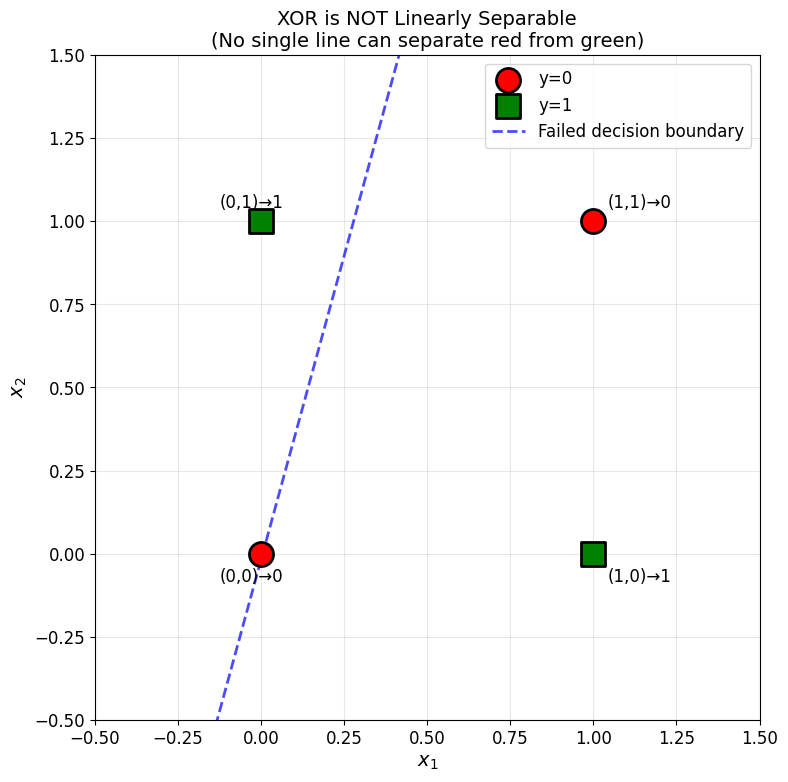

In [16]:
# Visualise XOR data points and failed decision boundary
fig, ax = plt.subplots(figsize=(8, 8))
# Plot points
for i in range(len(X_xor)):
    if y_xor[i] == 0:
        ax.scatter(X_xor[i, 0], X_xor[i, 1], c='red', marker='o', s=300,
            edgecolors='black', linewidths=2, zorder=5,
            label='y=0' if i == 0 else '')
    else:
        ax.scatter(X_xor[i, 0], X_xor[i, 1], c='green', marker='s', s=300,
            edgecolors='black', linewidths=2, zorder=5,
            label='y=1' if i == 1 else '')
# Add labels to points
ax.annotate('(0,0)→0', (0, 0), textcoords="offset points", xytext=(-30, -20), fontsize=12)
ax.annotate('(0,1)→1', (0, 1), textcoords="offset points", xytext=(-30, 10), fontsize=12)
ax.annotate('(1,0)→1', (1, 0), textcoords="offset points", xytext=(10, -20), fontsize=12)
ax.annotate('(1,1)→0', (1, 1), textcoords="offset points", xytext=(10, 10), fontsize=12)
# Plot the failed decision boundary
x1_range = np.linspace(-0.5, 1.5, 100)
if abs(perceptron_xor.weights[1]) > 1e-10:
    x2_boundary = -(perceptron_xor.weights[0] / perceptron_xor.weights[1]) * x1_range \
                    - (perceptron_xor.bias / perceptron_xor.weights[1])
    ax.plot(x1_range, x2_boundary, 'b--', linewidth=2, alpha=0.7,
            label='Failed decision boundary')
# Formatting
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('$x_1$', fontsize=14)
ax.set_ylabel('$x_2$', fontsize=14)
ax.set_title('XOR is NOT Linearly Separable\n(No single line can separate red from green)',
            fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Task 4.3: Visualise AND, OR, and XOR Together

Create a figure with three subplots showing:
1. AND with its decision boundary (separable)
2. OR with its decision boundary (separable)
3. XOR without a valid decision boundary (inseparable)

This visualisation should clearly demonstrate the concept of linear separability.

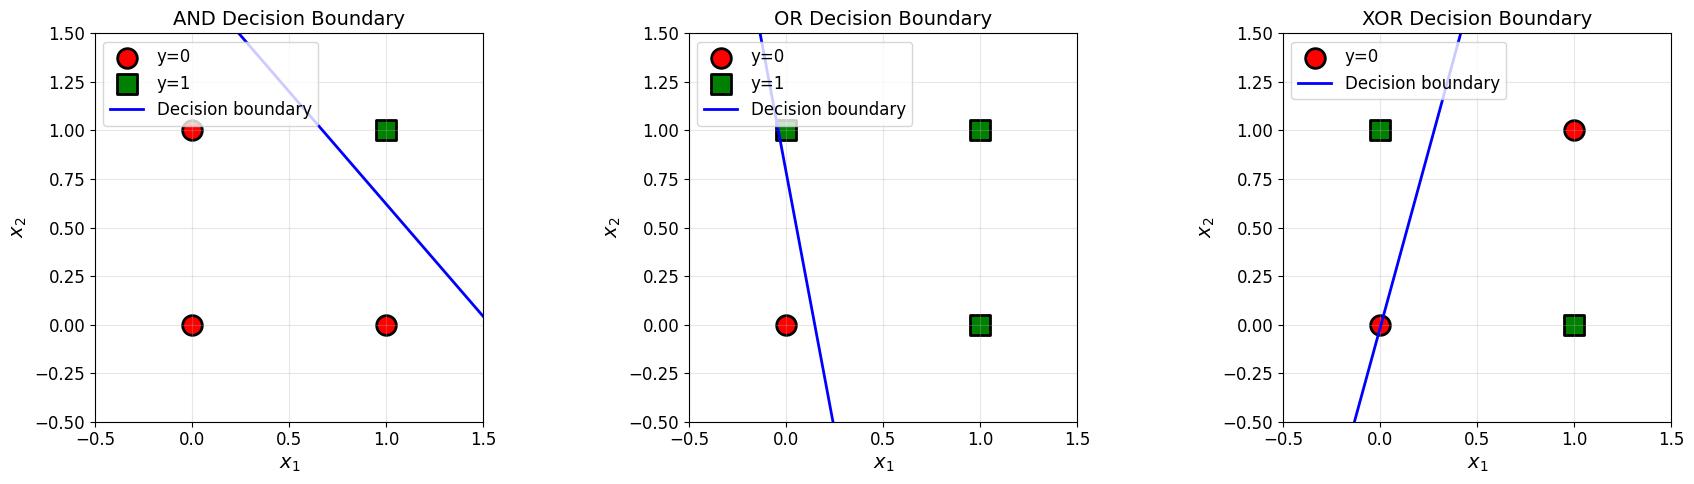

In [17]:
# Create 3-panel comparison figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
# TODO: add code to plot the AND decision boundary (i.e. a method call)
plot_decision_boundary(X_and, y_and, perceptron_and.weights, perceptron_and.bias,
"AND Decision Boundary", ax=ax1)
# TODO: add code to plot the OR decision boundary (i.e. a method call)
plot_decision_boundary(X_or, y_or, perceptron_or.weights, perceptron_or.bias,
"OR Decision Boundary", ax=ax2)
# TODO: add code to plot the XOR decision boundary (i.e. a method call)
plot_decision_boundary(X_xor, y_xor, perceptron_xor.weights, perceptron_xor.bias,
"XOR Decision Boundary", ax=ax3)

plt.tight_layout()
plt.show()

## Exercise 5: Two-Layer Perceptron for XOR

To solve XOR, we need a **two-layer perceptron** (also called a multi-layer perceptron or MLP).

### The Architecture

The XOR function can be expressed as:

$$\text{XOR}(x_1, x_2) = \text{AND}(\text{OR}(x_1, x_2), \text{NAND}(x_1, x_2))$$

Or equivalently, we can use two hyperplanes in the hidden layer:
- **Perceptron 1 (hidden):** Implements one linear boundary
- **Perceptron 2 (hidden):** Implements another linear boundary
- **Perceptron 3 (output):** Combines the outputs (AND-like operation)

```
        [Hidden Layer]        [Output Layer]
x1 ──┬──► Perceptron 1 ──┬──► Perceptron 3 ──► y
     │                   │
x2 ──┴──► Perceptron 2 ──┘
```

### Task 5.1: Implement with Pre-defined Weights

First, let's verify the architecture works by using weights that are known to solve XOR.

From the lecture slides, one valid configuration is:

**Hidden Layer:**
- **Perceptron 1:** $w_1 = -1.0, w_2 = -1.0, b = +1.5$ (implements $-x_1 - x_2 + 1.5 \geq 0$, i.e., at most one input is 1)
- **Perceptron 2:** $w_1 = +1.0, w_2 = +1.0, b = -0.5$ (implements $x_1 + x_2 \geq 0.5$, i.e., at least one input is 1)

**Output Layer:**
- **Perceptron 3:** $w_1 = +1.0, w_2 = +1.0, b = -1.5$ (fires when both h1=1 AND h2=1)

*Note: The exact weights may vary based on how you interpret the slide. The key is that hidden layer creates two parallel lines.*

In [18]:
# Two-layer perceptron with pre-defined weights
def xor_two_layer_manual(x1, x2, verbose=False):
    """
    Compute XOR using a two-layer perceptron with pre-defined weights.
    Architecture based on lecture slides (slide 45):
    - Hidden neuron 1: fires when at most one input is 1 (-x1 - x2 + 1.5 >= 0)
    - Hidden neuron 2: fires when at least one input is 1 (x1 + x2 >= 0.5)
    - Output neuron: h1 AND h2 (both hidden neurons must fire)
    Parameters:
    -----------
    x1, x2 : int
    Input values (0 or 1)
    verbose : bool
    If True, print intermediate calculations
    Returns:
    --------
    int : XOR result (0 or 1)
    """
    # Step function
    step = lambda x: 1 if x >= 0 else 0
    # Hidden layer (from slides)
    # Perceptron 1: w1=-1, w2=-1, b=+1.5 (fires when at most one input is 1)
    h1_sum = x1 * (-1) + x2 * (-1) + 1.5
    h1 = step(h1_sum)
    # Perceptron 2: w1=+1, w2=+1, b=-0.5 (fires when at least one input is 1)
    # TODO: add code here to compute Perceptron 2
    h2_sum = x1 * 1 + x2 * 1 - 0.5
    h2 = step(h2_sum)
    
    # Output layer
    # Perceptron 3: w1=+1, w2=+1, b=-1.5 (fires when h1 AND h2)
    # TODO: add code here to compute Perceptron 3
    y_sum = h1 * 1 + h2 * 1 - 1.5
    y = step(y_sum)
    
    if verbose:
        print(f" Input: ({x1}, {x2})")
        print(f" Hidden 1: {x1}*(-1) + {x2}*(-1) + 1.5 = {h1_sum:.1f} -> h1 = {h1}")
        print(f" Hidden 2: {x1}*1 + {x2}*1 - 0.5 = {h2_sum:.1f} -> h2 = {h2}")
        print(f" Output: {h1}*1 + {h2}*1 - 1.5 = {y_sum:.1f} -> y = {y}")
    return y
    # Test
print("Testing two-layer perceptron for XOR (manual weights):")
print("=" * 60)
all_correct = True
for x1 in [0, 1]:
    for x2 in [0, 1]:
        result = xor_two_layer_manual(x1, x2, verbose=True)
        expected = x1 ^ x2
        correct = "✓" if result == expected else "✗"
        if result != expected:
            all_correct = False
        print(f" Result: XOR({x1}, {x2}) = {result}, Expected: {expected} {correct}")
        print("-" * 40)
    print() 

Testing two-layer perceptron for XOR (manual weights):
 Input: (0, 0)
 Hidden 1: 0*(-1) + 0*(-1) + 1.5 = 1.5 -> h1 = 1
 Hidden 2: 0*1 + 0*1 - 0.5 = -0.5 -> h2 = 0
 Output: 1*1 + 0*1 - 1.5 = -0.5 -> y = 0
 Result: XOR(0, 0) = 0, Expected: 0 ✓
----------------------------------------
 Input: (0, 1)
 Hidden 1: 0*(-1) + 1*(-1) + 1.5 = 0.5 -> h1 = 1
 Hidden 2: 0*1 + 1*1 - 0.5 = 0.5 -> h2 = 1
 Output: 1*1 + 1*1 - 1.5 = 0.5 -> y = 1
 Result: XOR(0, 1) = 1, Expected: 1 ✓
----------------------------------------

 Input: (1, 0)
 Hidden 1: 1*(-1) + 0*(-1) + 1.5 = 0.5 -> h1 = 1
 Hidden 2: 1*1 + 0*1 - 0.5 = 0.5 -> h2 = 1
 Output: 1*1 + 1*1 - 1.5 = 0.5 -> y = 1
 Result: XOR(1, 0) = 1, Expected: 1 ✓
----------------------------------------
 Input: (1, 1)
 Hidden 1: 1*(-1) + 1*(-1) + 1.5 = -0.5 -> h1 = 0
 Hidden 2: 1*1 + 1*1 - 0.5 = 1.5 -> h2 = 1
 Output: 0*1 + 1*1 - 1.5 = -0.5 -> y = 0
 Result: XOR(1, 1) = 0, Expected: 0 ✓
----------------------------------------



### Task 5.2: Visualise the Two Hyperplanes

Plot the two decision boundaries from the hidden layer neurons.

**Key Insight:** The two lines divide the input space into three regions:
1. Below both lines (only h2 activates)
2. Between the lines (both h1 and h2 activate)
3. Above both lines (only h1 activates)

The output neuron then selects the region(s) where XOR should output 1.

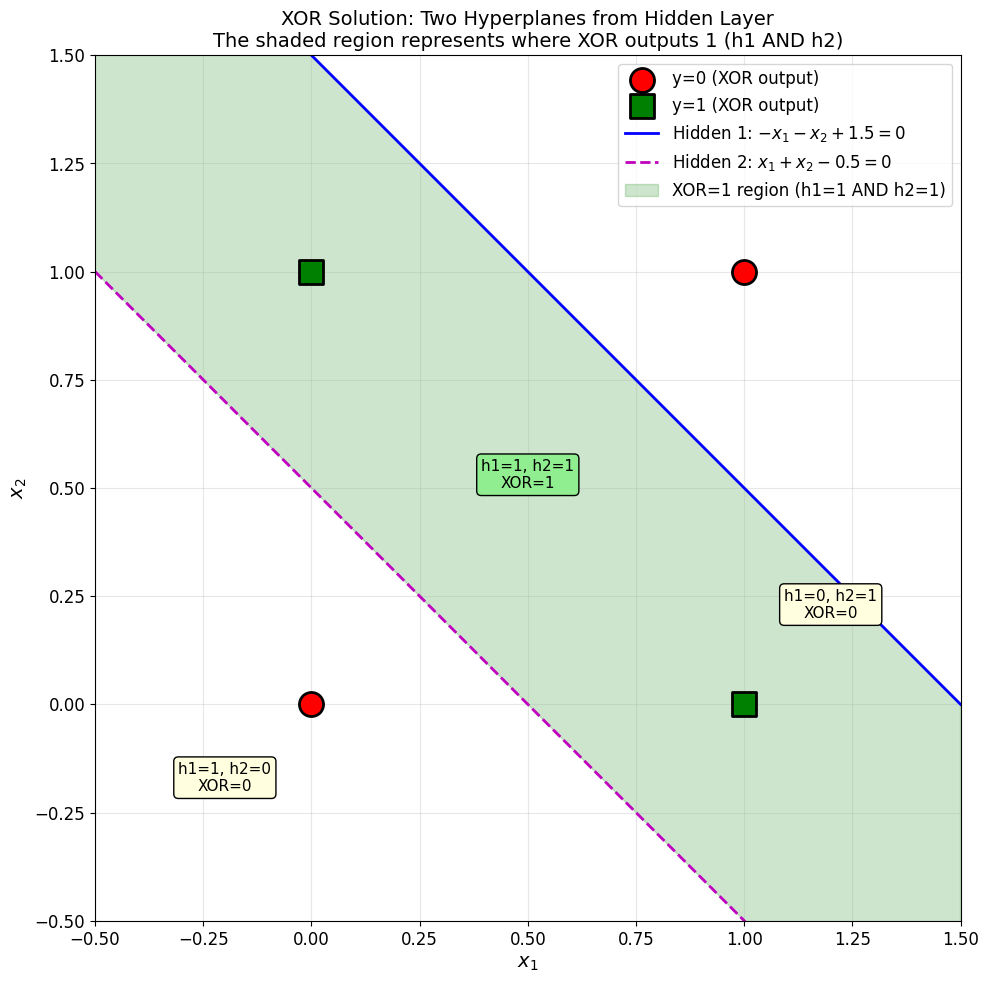

In [19]:
# Visualise the two hyperplanes from the hidden layer
fig, ax = plt.subplots(figsize=(10, 10))
# Plot data points
for i in range(len(X_xor)):
    if y_xor[i] == 0:
        ax.scatter(X_xor[i, 0], X_xor[i, 1], c='red', marker='o', s=300,
                    edgecolors='black', linewidths=2, zorder=5,
                    label='y=0 (XOR output)' if i == 0 else '')
    else:
        ax.scatter(X_xor[i, 0], X_xor[i, 1], c='green', marker='s', s=300,
                    edgecolors='black', linewidths=2, zorder=5,
                    label='y=1 (XOR output)' if i == 1 else '') 
        
# Define the two hyperplanes from hidden layer
x1_range = np.linspace(-0.5, 1.5, 100)
# Hidden neuron 1: -x1 - x2 + 1.5 = 0 => x2 = -x1 + 1.5
x2_h1 = -x1_range + 1.5
ax.plot(x1_range, x2_h1, 'b-', linewidth=2, label='Hidden 1: $-x_1 - x_2 + 1.5 = 0$')

# Hidden neuron 2: x1 + x2 - 0.5 = 0 => x2 = -x1 + 0.5
# TODO: add code here to compute x2 for this neuron
x2_h2 = -x1_range + 0.5

ax.plot(x1_range, x2_h2, 'm--', linewidth=2, label='Hidden 2: $x_1 + x_2 - 0.5 = 0$')

# Shade regions
# Region where XOR = 1 (between the two lines, where both h1=1 and h2=1)
ax.fill_between(x1_range, x2_h2, x2_h1, alpha=0.2, color='green',
                label='XOR=1 region (h1=1 AND h2=1)')

# Add annotations
ax.annotate('h1=1, h2=0\nXOR=0', xy=(-0.2, -0.2), fontsize=11, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax.annotate('h1=1, h2=1\nXOR=1', xy=(0.5, 0.5), fontsize=11, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightgreen'))

# TODO: Add code here to yellow-annotate the region where h1=0, h2=1, XOR=0
ax.annotate('h1=0, h2=1\nXOR=0', xy=(1.2, 0.2), fontsize=11, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Formatting
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('$x_1$', fontsize=14)
ax.set_ylabel('$x_2$', fontsize=14)
ax.set_title('XOR Solution: Two Hyperplanes from Hidden Layer\n'
                'The shaded region represents where XOR outputs 1 (h1 AND h2)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Task 5.3: Implement a Trainable Two-Layer Network

This is more advanced: implement a two-layer network that can learn the XOR weights through training.

**Important:** With step functions, training multi-layer networks is problematic because the step function is not differentiable. In practice, we use sigmoid or other smooth activation functions for training (to be covered in Lab 2).

For now, you could either:
1. Use the manual weights from Task 5.1.
2. Try a simple "evolutionary" approach: randomly adjust weights and keep improvements.
3. **Our approach:** use sigmoid activation and basic gradient descent (preview of Lab 2).

*Hint for option 3:* The sigmoid function is $\sigma(x) = \frac{1}{1 + e^{-x}}$ and its derivative is $\sigma'(x) = \sigma(x)(1 - \sigma(x))$

In [20]:
class TwoLayerPerceptron:
    """
    A two-layer perceptron (MLP) for XOR using sigmoid activation.
    This is a preview of Lab 2 concepts.
    """
    def __init__(self, input_size=2, hidden_size=2, output_size=1, learning_rate=0.5):
        """
        Initialise the network.
        """
        self.learning_rate = learning_rate
        
        # Weights: input -> hidden
        self.weights_ih = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.bias_h = np.random.uniform(-1, 1, hidden_size)
        
        # Weights: hidden -> output
        self.weights_ho = np.random.uniform(-1, 1, (hidden_size, output_size))
        self.bias_o = np.random.uniform(-1, 1, output_size)
        
    def sigmoid(self, x):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid: σ'(x) = σ(x)(1 - σ(x))."""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        """
        Forward pass through the network.
        Returns intermediate values needed for backpropagation.
        """
        # Input to hidden
        self.z_h = np.dot(X, self.weights_ih) + self.bias_h
        self.a_h = self.sigmoid(self.z_h)
        
        # Hidden to output
        self.z_o = np.dot(self.a_h, self.weights_ho) + self.bias_o
        self.a_o = self.sigmoid(self.z_o)
        
        return self.a_o
    
    def backward(self, X, y):
        """
        Backward pass (backpropagation).
        """
        m = X.shape[0] # Number of samples
        
        # Output layer error
        output_error = y - self.a_o
        output_delta = output_error * self.sigmoid_derivative(self.z_o)
        
        # Hidden layer error
        hidden_error = np.dot(output_delta, self.weights_ho.T)
        hidden_delta = hidden_error * self.sigmoid_derivative(self.z_h)
        
        # Update weights and biases
        self.weights_ho += self.learning_rate * np.dot(self.a_h.T, output_delta) / m
        self.bias_o += self.learning_rate * np.mean(output_delta, axis=0)
        
        self.weights_ih += self.learning_rate * np.dot(X.T, hidden_delta) / m
        self.bias_h += self.learning_rate * np.mean(hidden_delta, axis=0)
        
    def train(self, X, y, epochs, verbose_interval=1000):
        """
        Train the network.
        """
        losses = []
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)
            
            # Compute loss (MSE)
            loss = np.mean((output - y.reshape(-1, 1)) ** 2)
            losses.append(loss)
            
            # Backward pass
            self.backward(X, y)
            
            if epoch % verbose_interval == 0:
                print(f"Epoch {epoch}: Loss = {loss:.6f}")
                
        return losses
    
    def predict(self, X):
        """
        Make predictions (rounded to 0 or 1).
        """
        output = self.forward(X)
        return (output >= 0.5).astype(int).flatten()
    
# Train the network
print("Training two-layer network for XOR (with backpropagation):")
print("=" * 60)

np.random.seed(42)
y_xor = y_xor.reshape(-1, 1) # Reshape targets to (n_samples, 1)
mlp = TwoLayerPerceptron(hidden_size=4, learning_rate=2.0)

losses = mlp.train(X_xor, y_xor, epochs=10001, verbose_interval=2000)

# Test
print("\nTesting trained network:")
print("-" * 40)
predictions = mlp.predict(X_xor)

for i in range(len(X_xor)):
    correct = "✓" if predictions[i] == y_xor[i] else "✗"
    print(f"XOR({X_xor[i][0]}, {X_xor[i][1]}) = {predictions[i]}, Expected: {y_xor[i]} {correct}")
print("-" * 40)
accuracy = np.mean(predictions == y_xor.flatten()) * 100
print(f"Accuracy: {accuracy:.1f}%")

Training two-layer network for XOR (with backpropagation):
Epoch 0: Loss = 0.315398
Epoch 2000: Loss = 0.002133
Epoch 4000: Loss = 0.000789
Epoch 6000: Loss = 0.000475
Epoch 8000: Loss = 0.000338
Epoch 10000: Loss = 0.000262

Testing trained network:
----------------------------------------
XOR(0, 0) = 0, Expected: [0] ✓
XOR(0, 1) = 1, Expected: [1] ✓
XOR(1, 0) = 1, Expected: [1] ✓
XOR(1, 1) = 0, Expected: [0] ✓
----------------------------------------
Accuracy: 100.0%


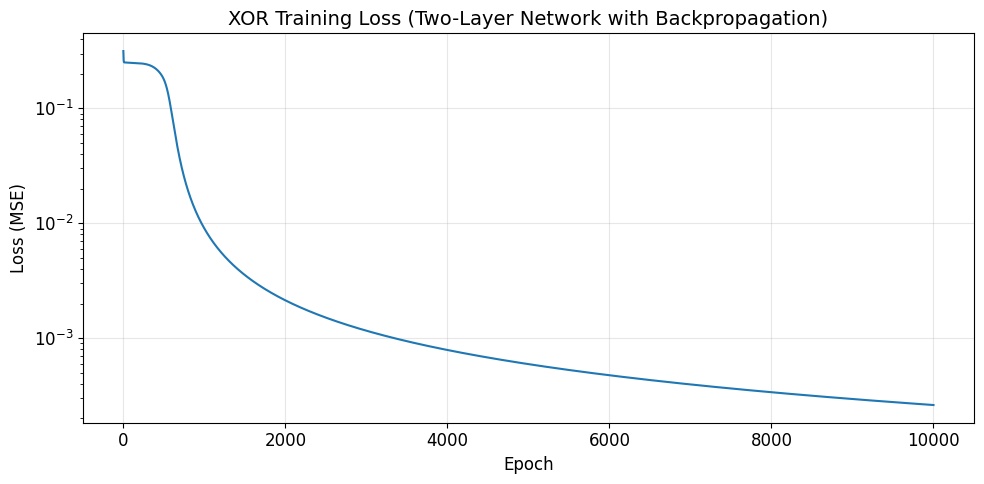

In [21]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('XOR Training Loss (Two-Layer Network with Backpropagation)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

## Exercise 6: NAND Perceptron
Train a perceptron to learn NAND (NOT AND). Verify that NAND is also linearly separable.

In [22]:
X_nand = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_nand = np.array([1, 1, 1, 0])
print("NAND Training Data:")
print("X:")
print(X_nand)
print("y:", y_nand)

NAND Training Data:
X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [1 1 1 0]


In [23]:
perceptron_nand = Perceptron(n_inputs=2, learning_rate=0.1)
print("Initial weights:", perceptron_nand.weights)
print("Initial bias:", perceptron_nand.bias)
print("\nTraining...\n")
history_nand = perceptron_nand.train(X_nand, y_nand, epochs=10)
print("\nTesting NAND perceptron:")
print("-" * 40)
all_correct = True
for i in range(len(X_nand)):
    prediction = perceptron_nand.predict(X_nand[i])
    correct = "✓" if prediction == y_nand[i] else "✗"
    if prediction != y_nand[i]:
        all_correct = False
    print(
        f"Input: {X_nand[i]} -> Predicted: {prediction}, Expected: {y_nand[i]} {correct}"
    )
print("-" * 40)
print(f"All predictions correct: {all_correct}")

Initial weights: [ 0.02475643 -0.06805498]
Initial bias: -0.2087708598019581

Training...

Epoch 1: weights = [-0.07524357 -0.06805498], bias = -0.1088, errors = 3
Epoch 2: weights = [-0.17524357 -0.06805498], bias = -0.0088, errors = 3
Epoch 3: weights = [-0.17524357 -0.16805498], bias = 0.0912, errors = 3
Epoch 4: weights = [-0.17524357 -0.06805498], bias = 0.1912, errors = 1
Epoch 5: weights = [-0.17524357 -0.06805498], bias = 0.1912, errors = 0
Converged after 5 epochs!

Testing NAND perceptron:
----------------------------------------
Input: [0 0] -> Predicted: 1, Expected: 1 ✓
Input: [0 1] -> Predicted: 1, Expected: 1 ✓
Input: [1 0] -> Predicted: 1, Expected: 1 ✓
Input: [1 1] -> Predicted: 0, Expected: 0 ✓
----------------------------------------
All predictions correct: True


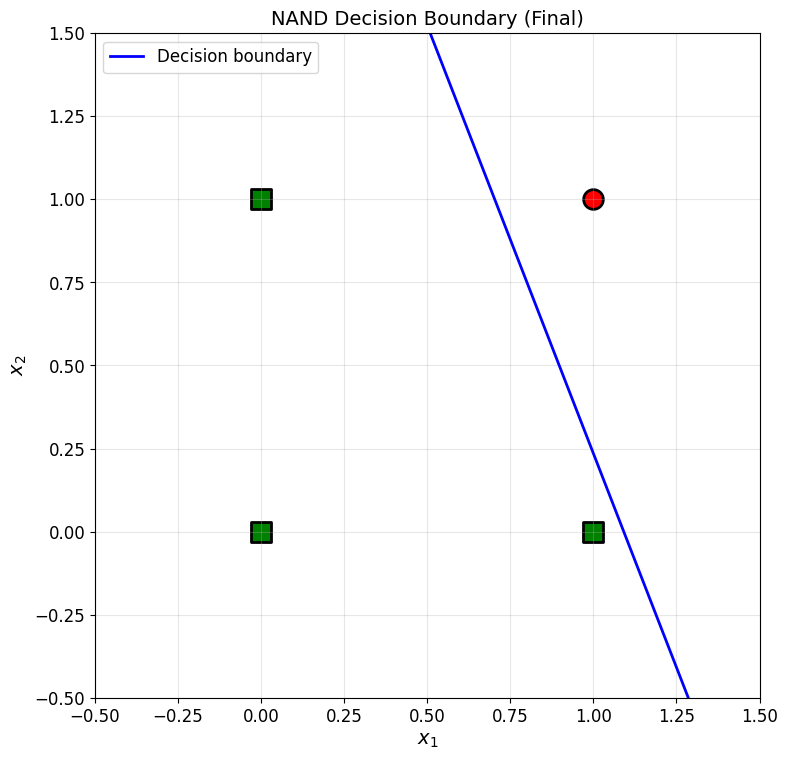

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_decision_boundary(
    X_nand,
    y_nand,
    perceptron_nand.weights,
    perceptron_nand.bias,
    "NAND Decision Boundary (Final)",
    ax=ax
)
plt.tight_layout()
plt.show()

## Exercise 7: Learning Rate Experiments
Try different learning rates (0.01, 0.1, 0.5, 1.0) for AND training. How does the learning rate affect:  
    - Number of epochs to converge?  
    - Stability of training?  
    - Final weights?  

LR=0.01: Converged in 20 epochs, Final weights: [-0.14545988  0.26071431], bias: -0.0980
LR=0.1: Converged in 7 epochs, Final weights: [0.17454012 0.15071431], bias: -0.2680
LR=0.5: Converged in 6 epochs, Final weights: [0.87454012 0.45071431], bias: -1.2680
LR=1.0: Converged in 6 epochs, Final weights: [1.87454012 1.45071431], bias: -2.7680


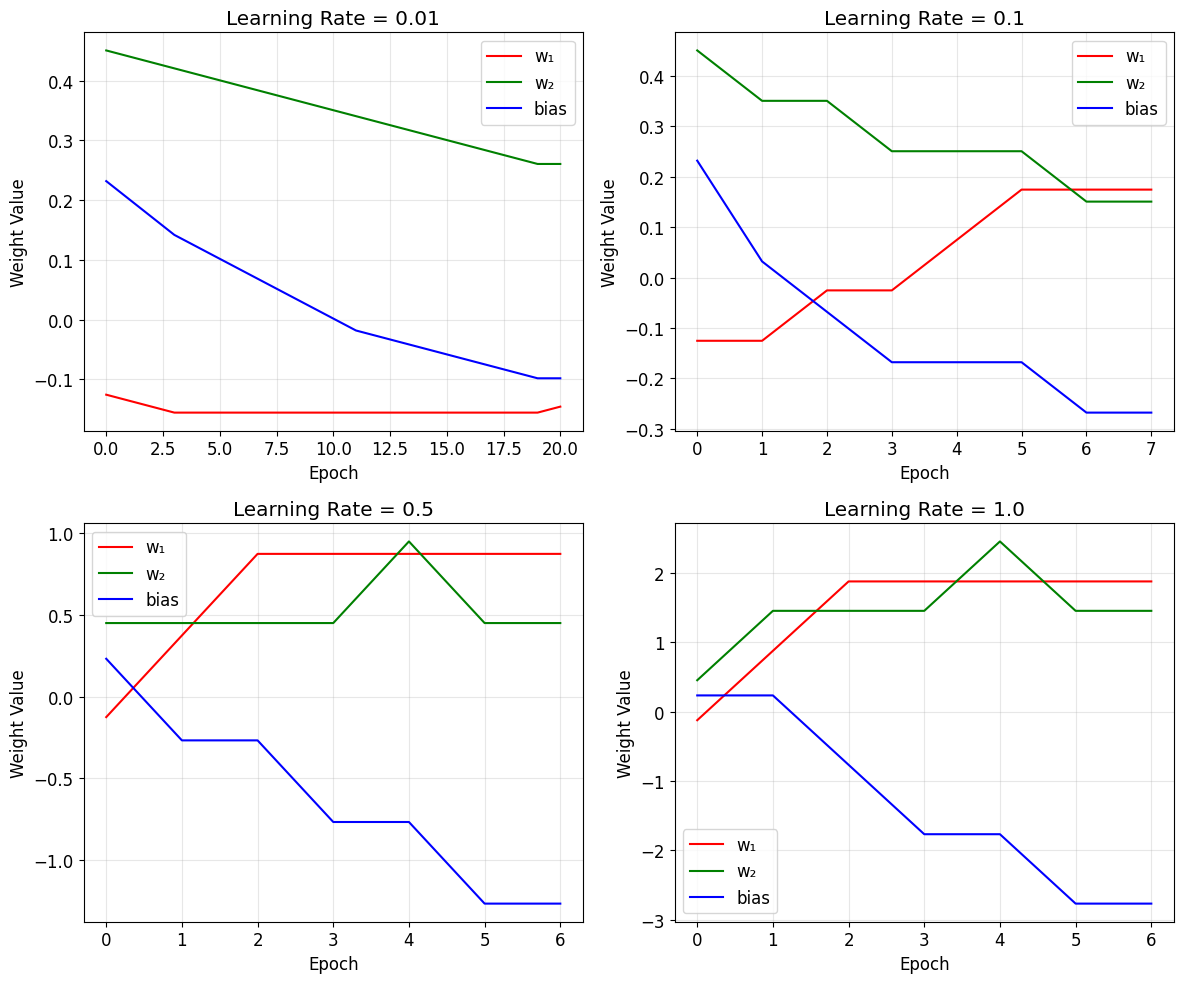

In [25]:
learning_rates = [0.01, 0.1, 0.5, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, lr in enumerate(learning_rates):
    np.random.seed(42) # Same starting point
    
    # TODO: add code here to create Perceptron 'p' with learning rate 'lr'
    p = Perceptron(n_inputs=2, learning_rate=lr)
    
    # TODO: add code here to train the perceptron and record history
    ## Hint: set verbose to False
    history = p.train(X_and, y_and, epochs=20, verbose=False)
    
    ax = axes[idx // 2, idx % 2]
    # Plot weight evolution
    epochs = range(len(history))
    w1_vals = [h[0][0] for h in history]
    w2_vals = [h[0][1] for h in history]
    b_vals = [h[1] for h in history]
    
    ax.plot(epochs, w1_vals, 'r-', label='w₁')
    ax.plot(epochs, w2_vals, 'g-', label='w₂')
    ax.plot(epochs, b_vals, 'b-', label='bias')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Weight Value')
    ax.set_title(f'Learning Rate = {lr}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"LR={lr}: Converged in {len(history)-1} epochs, Final weights: {p.weights}, bias: {p.bias:.4f}")
    
plt.tight_layout()
plt.show()

## Exercise 8: 3-Input AND
Extend your perceptron to handle 3 inputs and train on 3-input AND. How does this change the
visualisation challenge?

In [26]:
# 3-input AND gate
X_and3 = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1],
                   [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]])
y_and3 = np.array([0, 0, 0, 0, 0, 0, 0, 1])
print("3-input AND Training Data:")
print("X:")
print(X_and3)
print("y:", y_and3)

3-input AND Training Data:
X:
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]
y: [0 0 0 0 0 0 0 1]


In [27]:
perceptron_and3 = Perceptron(n_inputs=3, learning_rate=0.1)
print("Initial weights:", perceptron_and3.weights)
print("Initial bias:", perceptron_and3.bias)
print("\nTraining...\n")
history_and3 = perceptron_and3.train(X_and3, y_and3, epochs=20)
print("\nTesting 3-input AND perceptron:")
print("-" * 40)
all_correct = True
for i in range(len(X_and3)):
    prediction = perceptron_and3.predict(X_and3[i])
    correct = "✓" if prediction == y_and3[i] else "✗"
    if prediction != y_and3[i]:
        all_correct = False
    print(
        f"Input: {X_and3[i]} -> Predicted: {prediction}, Expected: {y_and3[i]} {correct}"
    )
print("-" * 40)
print(f"All predictions correct: {all_correct}")
print(f"Final weights: {perceptron_and3.weights}, bias: {perceptron_and3.bias:.4f}")

Initial weights: [ 0.09865848 -0.34398136 -0.34400548]
Initial bias: -0.44191638783180054

Training...

Epoch 1: weights = [ 0.19865848 -0.24398136 -0.24400548], bias = -0.3419, errors = 1
Epoch 2: weights = [ 0.29865848 -0.14398136 -0.14400548], bias = -0.2419, errors = 1
Epoch 3: weights = [ 0.29865848 -0.04398136 -0.04400548], bias = -0.2419, errors = 2
Epoch 4: weights = [0.29865848 0.05601864 0.05599452], bias = -0.2419, errors = 2
Epoch 5: weights = [0.29865848 0.15601864 0.15599452], bias = -0.2419, errors = 2
Epoch 6: weights = [0.29865848 0.15601864 0.05599452], bias = -0.3419, errors = 3
Epoch 7: weights = [0.29865848 0.25601864 0.05599452], bias = -0.3419, errors = 2
Epoch 8: weights = [0.19865848 0.25601864 0.05599452], bias = -0.4419, errors = 3
Epoch 9: weights = [0.19865848 0.25601864 0.15599452], bias = -0.4419, errors = 2
Epoch 10: weights = [0.19865848 0.25601864 0.25599452], bias = -0.4419, errors = 2
Epoch 11: weights = [0.29865848 0.25601864 0.25599452], bias = -0.

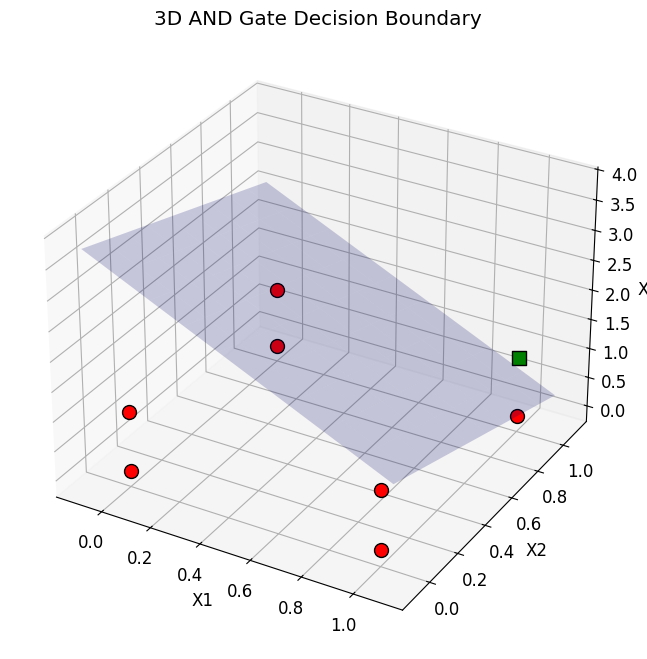

In [28]:
from mpl_toolkits.mplot3d import Axes3D

def plot_decision_boundary_3d(X, y, weights, bias):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the data points
    colors = ['red' if val == 0 else 'green' for val in y]
    markers = ['o' if val == 0 else 's' for val in y]
    
    for i in range(len(X)):
        ax.scatter(X[i, 0], X[i, 1], X[i, 2], c=colors[i], marker=markers[i], s=100, edgecolors='k')

    # 2. Create a meshgrid for the plane
    x1_range = np.linspace(-0.1, 1.1, 10)
    x2_range = np.linspace(-0.1, 1.1, 10)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    
    # 3. Calculate the corresponding X3 (Z) values for the plane
    # Equation: w1*x1 + w2*x2 + w3*x3 + b = 0  => x3 = -(w1*x1 + w2*x2 + b) / w3
    if abs(weights[2]) > 1e-10:
        X3 = -(weights[0] * X1 + weights[1] * X2 + bias) / weights[2]
        # Plot the surface
        ax.plot_surface(X1, X2, X3, alpha=0.2, color='blue')
    
    # Labeling
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('3D AND Gate Decision Boundary')
    
    plt.show()

# Call the function
plot_decision_boundary_3d(X_and3, y_and3, perceptron_and3.weights, perceptron_and3.bias)

## Exercise 9: Zoo Dataset Preview
The Zoo dataset has 16 binary attributes per animal. Think about how a perceptron with 16 inputs would
work. What would the decision boundary look like in 16-dimensional space? (Answer: it's a 15-
dimensional hyperplane!)

In [29]:
print("Exercise 9: Zoo Dataset Preview")
print("=" * 60)
# The Zoo dataset has 101 animals with 16 binary attributes:
# hair, feathers, eggs, milk, airborne, aquatic, predator, toothed,
# backbone, breathes, venomous, fins, legs (0,2,4,5,6,8), tail, domestic, catsize
#
# Plus a class label (1-7): Mammal, Bird, Reptile, Fish, Amphibian, Bug, Invertebrate
# For this exercise, we'll create a simplified binary classification:
# Can a perceptron distinguish Mammals (class 1) from Non-Mammals?
# Sample data from Zoo dataset (simplified - using key attributes)
# Format: [hair, feathers, eggs, milk, airborne, aquatic, predator, toothed,
# backbone, breathes, venomous, fins, tail, domestic, catsize]
# Note: 'legs' omitted as it's not strictly binary

# Some mammals (class 1)
mammals = np.array([
[1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1], # aardvark
[1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1], # antelope
[1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1], # bear
[1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1], # cat
[1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1], # dog
[1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1], # elephant
[1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1], # deer
[0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1], # dolphin (no hair!)
])

# Some non-mammals
non_mammals = np.array([
[0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0], # chicken (bird)
[0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0], # hawk (bird)
[0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0], # bass (fish)
[0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0], # carp (fish)
[0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0], # frog (amphibian)
[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # honeybee (bug)
[0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0], # wasp (bug)
[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0], # scorpion (invertebrate)
])

# Combine into training data
X_zoo = np.vstack([mammals, non_mammals])
y_zoo = np.array([1]*len(mammals) + [0]*len(non_mammals)) # 1=mammal, 0=non-mammal
print(f"Dataset: {len(X_zoo)} animals, {X_zoo.shape[1]} features")
print(f"Mammals: {sum(y_zoo)}, Non-mammals: {len(y_zoo) - sum(y_zoo)}")
print()

# Train a perceptron
np.random.seed(42)

## TODO: add code here to create a Perceptron with 15 inputs and learning rate 0.1
perceptron_zoo = Perceptron(n_inputs=15, learning_rate=0.1)

print("Training perceptron for Mammal vs Non-Mammal classification...")
history_zoo = perceptron_zoo.train(X_zoo, y_zoo, epochs=50, verbose=False)
print(f"Training completed in {len(history_zoo)-1} epochs.")
print()

# Test
print("Testing:")
print("-" * 50)
animal_names = ['aardvark', 'antelope', 'bear', 'cat', 'dog', 'elephant', 'deer', 'dolphin',
'chicken', 'hawk', 'bass', 'carp', 'frog', 'honeybee', 'wasp', 'scorpion']

n_correct = 0
for i in range(len(X_zoo)):
    pred = perceptron_zoo.predict(X_zoo[i])
    expected = y_zoo[i]
    correct = "✓" if pred == expected else "✗"
    if pred == expected:
        n_correct += 1
    label = "Mammal" if pred == 1 else "Non-mammal"
    print(f"{animal_names[i]:12} -> Predicted: {label:11} ({pred}), Expected: {expected} {correct}")
    
print("-" * 50)
print(f"Accuracy: {n_correct}/{len(X_zoo)} = {n_correct/len(X_zoo)*100:.1f}%")
print()
print("Key observations:")
print("1. With 15 inputs, the decision boundary is a 14-dimensional hyperplane!")
print("2. The 'milk' attribute (index 3) is very predictive of mammals.")
print("3. A single perceptron can only do binary classification (2 classes).")
print("4. For 7-class Zoo classification, we'd need a different approach (Lab 2).")

# Show which features have highest weights
feature_names = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
                'predator', 'toothed', 'backbone', 'breathes', 'venomous',
                'fins', 'tail', 'domestic', 'catsize']

print("\nLearned weights (magnitude indicates importance):")
sorted_indices = np.argsort(np.abs(perceptron_zoo.weights))[::-1]

for idx in sorted_indices[:5]: # Top 5 features
    print(f" {feature_names[idx]:12}: {perceptron_zoo.weights[idx]:+.4f}")

Exercise 9: Zoo Dataset Preview
Dataset: 16 animals, 15 features
Mammals: 8, Non-mammals: 8

Training perceptron for Mammal vs Non-Mammal classification...
Training completed in 3 epochs.

Testing:
--------------------------------------------------
aardvark     -> Predicted: Mammal      (1), Expected: 1 ✓
antelope     -> Predicted: Mammal      (1), Expected: 1 ✓
bear         -> Predicted: Mammal      (1), Expected: 1 ✓
cat          -> Predicted: Mammal      (1), Expected: 1 ✓
dog          -> Predicted: Mammal      (1), Expected: 1 ✓
elephant     -> Predicted: Mammal      (1), Expected: 1 ✓
deer         -> Predicted: Mammal      (1), Expected: 1 ✓
dolphin      -> Predicted: Mammal      (1), Expected: 1 ✓
chicken      -> Predicted: Non-mammal  (0), Expected: 0 ✓
hawk         -> Predicted: Non-mammal  (0), Expected: 0 ✓
bass         -> Predicted: Non-mammal  (0), Expected: 0 ✓
carp         -> Predicted: Non-mammal  (0), Expected: 0 ✓
frog         -> Predicted: Non-mammal  (0), Expected: 0

## Exercise 10: Zoo Dataset Classification

**Module:** Artificial Intelligence  
**Lab:** 1 (Perceptrons and Linear Separability)  
**Topic:** Mammals vs Non-Mammals Classification

### Objectives

In this exercise, you will:
1. Load and explore the UCI Zoo dataset
2. Investigate which features make mammal classification "easy"
3. Use the two-layer network from Task 5.3 when key features are removed
4. Apply one-hot encoding for the "legs" feature

### Task 10.1: Load the Zoo Dataset

We'll load the dataset directly from the UCI ML Repository using the `ucimlrepo` package.

In [30]:
# Load Zoo dataset from UCI ML Repository
from ucimlrepo import fetch_ucirepo

zoo = fetch_ucirepo(id=111)

# Extract components
# - zoo.data.features: DataFrame with feature columns
# - zoo.data.targets: DataFrame with class labels
# - zoo.data.ids: DataFrame with animal names

# Get feature matrix and names
features_df = zoo.data.features
feature_names = features_df.columns.tolist()
features_raw = features_df.values

# Get target (class type: 1=Mammal, 2=Bird, 3=Reptile, 4=Fish,
# 5=Amphibian, 6=Bug, 7=Invertebrate)
class_labels = zoo.data.targets.values.flatten()

# Get animal names from the 'ids' DataFrame
animal_names = zoo.data.ids.iloc[:, 0].tolist()

# Binary target: Mammal (1) vs Non-Mammal (0)
y = (class_labels == 1).astype(int)

print(f"Dataset: {len(animal_names)} animals, {features_raw.shape[1]} features")
print(f"Mammals: {np.sum(y)}, Non-mammals: {np.sum(1-y)}")
print(f"\nFeature names: {feature_names}")
print(f"\nLegs values in dataset: { 
      sorted(set(features_raw[:, feature_names.index('legs')]))
}")
print(f"\nFirst 5 animals: {animal_names[:5]}")

Dataset: 101 animals, 16 features
Mammals: 41, Non-mammals: 60

Feature names: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']

Legs values in dataset: [np.int64(0), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(8)]

First 5 animals: ['aardvark', 'antelope', 'bass', 'bear', 'boar']


### Task 10.2: One-Hot Encoding for Legs

The "legs" attribute takes categorical values: 0, 2, 4, 5, 6, 8.

**Why not normalise?** Normalising (e.g., legs/8) implies a meaningful ordering where 8 > 6 > 4, but there's no biological reason why having more legs makes an animal more or less mammalian. A whale (0 legs) and a dog (4 legs) are both mammals.

**One-hot encoding** treats each leg count as an independent category:

| legs | legs_0 | legs_2 | legs_4 | legs_5 | legs_6 | legs_8 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 1 | 0 | 0 | 0 | 0 | 0 |
| 4 | 0 | 0 | 1 | 0 | 0 | 0 |
| 6 | 0 | 0 | 0 | 0 | 1 | 0 |

In [31]:
# Get unique leg values from the dataset
legs_idx = feature_names.index('legs')
leg_categories = sorted(set(int(x) for x in features_raw[:, legs_idx]))
print(f"Leg categories found: {leg_categories}")

def encode_legs_onehot(legs_values, categories):
    """One-hot encoding for legs using the categories found in data."""
    encoded = np.zeros((len(legs_values), len(categories)))
    
    for i, legs in enumerate(legs_values):
        if int(legs) in categories:
            encoded[i, categories.index(int(legs))] = 1
            
    return encoded

def prepare_features(X_raw, feature_names, remove_features=None):
    """
    Prepare features: remove specified features, one-hot encode legs.
    """
    if remove_features is None:
        remove_features = []
        
    legs_idx = feature_names.index('legs')
    legs_values = X_raw[:, legs_idx]
    
    # Get indices to keep (exclude legs and any features to remove)
    remove_indices = [feature_names.index(f) for f in remove_features] + [legs_idx]
    keep_indices = [i for i in range(len(feature_names)) if i not in remove_indices]
    
    # Build feature matrix
    X_binary = X_raw[:, keep_indices].astype(float)
    X_legs = encode_legs_onehot(legs_values, leg_categories)
    X = np.hstack([X_binary, X_legs])
    
    # Build feature names
    kept_names = [feature_names[i] for i in keep_indices]
    legs_names = [f'legs_{c}' for c in leg_categories]
    new_feature_names = kept_names + legs_names
    
    return X, new_feature_names

# Prepare full feature set
X_full, feature_names_full = prepare_features(features_raw, feature_names)
print(f"\nFull feature set: {X_full.shape[1]} features")
print(f"Features: {feature_names_full}")

Leg categories found: [0, 2, 4, 5, 6, 8]

Full feature set: 21 features
Features: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'tail', 'domestic', 'catsize', 'legs_0', 'legs_2', 'legs_4', 'legs_5', 'legs_6', 'legs_8']


### Task 10.3: Train/Test Split

We'll hold out some interesting edge-case animals for testing:

| Animal | Class | Why interesting |
|--------|-------|-----------------|
| Dolphin | Mammal | No hair, aquatic, has fins |
| Platypus | Mammal | Lays eggs! |
| Seal | Mammal | Aquatic |
| Penguin | Bird | Aquatic, can't fly |
| Frog | Amphibian | 4 legs like mammals |
| Tortoise | Reptile | 4 legs like mammals |

In [32]:
test_animals = ['dolphin', 'platypus', 'seal', 'penguin', 'frog', 'tortoise']
test_indices = [animal_names.index(name) for name in test_animals]
train_indices = [i for i in range(len(animal_names)) if i not in test_indices]

X_train_raw = features_raw[train_indices]
y_train = y[train_indices]
X_test_raw = features_raw[test_indices]
y_test = y[test_indices]
test_names = [animal_names[i] for i in test_indices]

print(f"Training set: {len(X_train_raw)} animals")
print(f"Test set: {len(X_test_raw)} animals")
print(f"\nTest animals and their true labels (1=mammal):")

for name, label in zip(test_names, y_test):
    print(f" {name}: {label}")

Training set: 95 animals
Test set: 6 animals

Test animals and their true labels (1=mammal):
 dolphin: 1
 platypus: 1
 seal: 1
 penguin: 0
 frog: 0
 tortoise: 0


### Task 10.4: Experiment 1 - All Features (Including Milk)

**Question:** Can the network easily classify mammals when we include ALL features?

In [33]:
X_train_all, feat_names_all = prepare_features(X_train_raw, feature_names,
remove_features=[])
X_test_all, _ = prepare_features(X_test_raw, feature_names, remove_features=[])

# Reshape targets for TwoLayerPerceptron
y_train_2d = y_train.reshape(-1, 1)

print("Experiment 1: All features (including milk)")
print("=" * 50)
print(f"Features ({len(feat_names_all)}): {feat_names_all}")

np.random.seed(42)
mlp_all = TwoLayerPerceptron(input_size=X_train_all.shape[1], hidden_size=16,
            learning_rate=0.5)
losses = mlp_all.train(X_train_all, y_train_2d, epochs=3000, verbose_interval=1000)

# Evaluate
train_pred = mlp_all.predict(X_train_all)
train_acc = np.mean(train_pred == y_train) * 100

test_pred = mlp_all.predict(X_test_all)
test_acc = np.mean(test_pred == y_test) * 100

print(f"\nTraining accuracy: {train_acc:.1f}%")
print(f"Test accuracy: {test_acc:.1f}%")

print("\nTest predictions:")
for name, pred, true in zip(test_names, test_pred, y_test):
    correct = '✓' if pred == true else '✗'
    print(f" {name:12s}: predicted={pred}, actual={true} {correct}")

Experiment 1: All features (including milk)
Features (21): ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'tail', 'domestic', 'catsize', 'legs_0', 'legs_2', 'legs_4', 'legs_5', 'legs_6', 'legs_8']
Epoch 0: Loss = 0.304658
Epoch 1000: Loss = 0.002239
Epoch 2000: Loss = 0.000949

Training accuracy: 100.0%
Test accuracy: 100.0%

Test predictions:
 dolphin     : predicted=1, actual=1 ✓
 platypus    : predicted=1, actual=1 ✓
 seal        : predicted=1, actual=1 ✓
 penguin     : predicted=0, actual=0 ✓
 frog        : predicted=0, actual=0 ✓
 tortoise    : predicted=0, actual=0 ✓


### Task 10.5: Experiment 2 - Remove "Milk"

Let's make the problem harder by removing the most discriminative feature.

In [34]:
X_train_no_milk, feat_names_no_milk = prepare_features(X_train_raw, feature_names,
                                        remove_features=['milk'])
X_test_no_milk, _ = prepare_features(X_test_raw, feature_names, remove_features=['milk'])

print("Experiment 2: Without 'milk'")
print("=" * 50)
print(f"Features ({len(feat_names_no_milk)}): {feat_names_no_milk}")

np.random.seed(42)
mlp_no_milk = TwoLayerPerceptron(input_size=X_train_no_milk.shape[1], hidden_size=16,
                learning_rate=0.5)
losses = mlp_no_milk.train(X_train_no_milk, y_train_2d, epochs=3000, verbose_interval=1000)

# Evaluate
train_pred = mlp_no_milk.predict(X_train_no_milk)
train_acc = np.mean(train_pred == y_train) * 100

test_pred = mlp_no_milk.predict(X_test_no_milk)
test_acc = np.mean(test_pred == y_test) * 100

print(f"\nTraining accuracy: {train_acc:.1f}%")
print(f"Test accuracy: {test_acc:.1f}%")

print("\nTest predictions:")
for name, pred, true in zip(test_names, test_pred, y_test):
    correct = '✓' if pred == true else '✗'
    print(f" {name:12s}: predicted={pred}, actual={true} {correct}")

Experiment 2: Without 'milk'
Features (20): ['hair', 'feathers', 'eggs', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'tail', 'domestic', 'catsize', 'legs_0', 'legs_2', 'legs_4', 'legs_5', 'legs_6', 'legs_8']
Epoch 0: Loss = 0.216758
Epoch 1000: Loss = 0.008392
Epoch 2000: Loss = 0.002289

Training accuracy: 100.0%
Test accuracy: 83.3%

Test predictions:
 dolphin     : predicted=1, actual=1 ✓
 platypus    : predicted=0, actual=1 ✗
 seal        : predicted=1, actual=1 ✓
 penguin     : predicted=0, actual=0 ✓
 frog        : predicted=0, actual=0 ✓
 tortoise    : predicted=0, actual=0 ✓


### Task 10.6: Experiment 3 - Remove "Milk", "Hair", and "Eggs"

In [35]:
X_train_reduced, feat_names_reduced = prepare_features(X_train_raw, feature_names,
                                        remove_features=['milk', 'hair', 'eggs'])   
X_test_reduced, _ = prepare_features(X_test_raw, feature_names,
                        remove_features=['milk', 'hair', 'eggs'])

print("Experiment 3: Without 'milk', 'hair', and 'eggs'")
print("=" * 50)
print(f"Features ({len(feat_names_reduced)}): {feat_names_reduced}")

np.random.seed(42)
mlp_reduced = TwoLayerPerceptron(input_size=X_train_reduced.shape[1], hidden_size=16,
                learning_rate=0.5)
losses = mlp_reduced.train(X_train_reduced, y_train_2d, epochs=5000, verbose_interval=1000)

# Evaluate
train_pred = mlp_reduced.predict(X_train_reduced)
train_acc = np.mean(train_pred == y_train) * 100

test_pred = mlp_reduced.predict(X_test_reduced)
test_acc = np.mean(test_pred == y_test) * 100

print(f"\nTraining accuracy: {train_acc:.1f}%")
print(f"Test accuracy: {test_acc:.1f}%")

print("\nTest predictions:")
for name, pred, true in zip(test_names, test_pred, y_test):
    correct = '✓' if pred == true else '✗'
    print(f" {name:12s}: predicted={pred}, actual={true} {correct}")

Experiment 3: Without 'milk', 'hair', and 'eggs'
Features (18): ['feathers', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'tail', 'domestic', 'catsize', 'legs_0', 'legs_2', 'legs_4', 'legs_5', 'legs_6', 'legs_8']
Epoch 0: Loss = 0.249187
Epoch 1000: Loss = 0.020826
Epoch 2000: Loss = 0.014094
Epoch 3000: Loss = 0.011222
Epoch 4000: Loss = 0.009820

Training accuracy: 98.9%
Test accuracy: 50.0%

Test predictions:
 dolphin     : predicted=1, actual=1 ✓
 platypus    : predicted=0, actual=1 ✗
 seal        : predicted=0, actual=1 ✗
 penguin     : predicted=0, actual=0 ✓
 frog        : predicted=0, actual=0 ✓
 tortoise    : predicted=1, actual=0 ✗


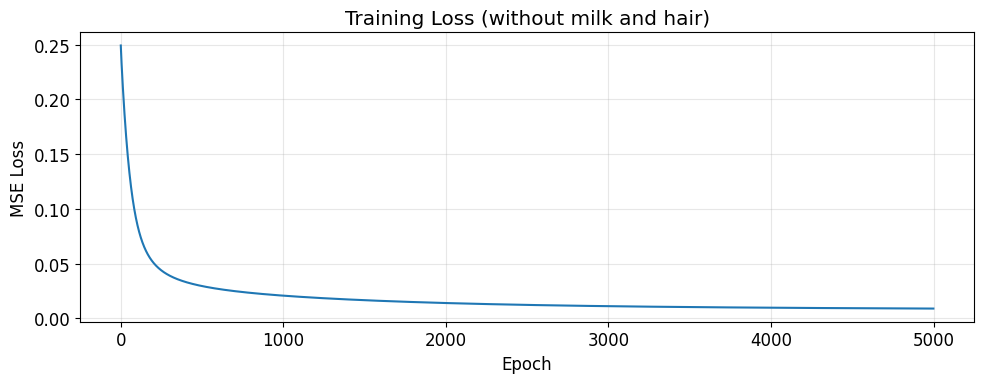

In [36]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (without milk and hair)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 10.7: Analysis - The Platypus Problem

The **platypus** is particularly challenging. Let's examine why:

In [37]:
platypus_idx = animal_names.index('platypus')
platypus_features = features_raw[platypus_idx]

print("Platypus features:")
print("=" * 40)
for name, val in zip(feature_names, platypus_features):
    marker = "← unusual for mammal!" if (name == 'eggs' and val == 1) else ""
    print(f" {name:12s}: {int(val)} {marker}")
    
print(f"\nClass: Mammal (class 1)")
print("\nThe platypus is a monotreme - a mammal that lays eggs!")
print("This makes it an outlier that confuses the classifier.")

Platypus features:
 hair        : 1 
 feathers    : 0 
 eggs        : 1 ← unusual for mammal!
 milk        : 1 
 airborne    : 0 
 aquatic     : 1 
 predator    : 1 
 toothed     : 0 
 backbone    : 1 
 breathes    : 1 
 venomous    : 0 
 fins        : 0 
 legs        : 4 
 tail        : 1 
 domestic    : 0 
 catsize     : 1 

Class: Mammal (class 1)

The platypus is a monotreme - a mammal that lays eggs!
This makes it an outlier that confuses the classifier.


## Summary and Key Takeaways

In this lab, you have, among other things:

1. **Implemented a Rosenblatt perceptron** from scratch, including the perceptron learning rule
2. **Trained perceptrons for AND and OR**, observing:
   - Weight convergence over epochs
   - Decision boundary adaptation
3. **Discovered the linear separability limitation** by attempting to solve XOR with a single perceptron
4. **Solved XOR with a two-layer perceptron**, understanding:
   - Why multiple layers are needed
   - How multiple hyperplanes can create non-linear decision regions

### Key Equations Revisited

**Perceptron output:**
$$y = \text{step}\left(\sum_{i=1}^{n} x_i \cdot w_i + b\right)$$

**Weight update rule:**
$$w_i^{(\text{new})} = w_i^{(\text{old})} + \alpha \cdot (y_d - y) \cdot x_i$$

**Decision boundary (2D):**
$$w_1 \cdot x_1 + w_2 \cdot x_2 + b = 0$$

### Preparation for Lab 2

In the next lab, we will:
- Replace the step function with **sigmoid activation** (which is differentiable, enabling gradient-based training)
- Implement **backpropagation** to train multi-layer networks automatically
- Train networks on real datasets (Iris, etc.)
- Evaluate performance using **confusion matrices** and other metrics

*Note: The two-layer XOR network in Task 5.1 used manually chosen weights. Task 5.3 gave a preview of sigmoid and backpropagation, but Lab 2 will cover these concepts properly and in depth.*